## Download all dependencies

In [1]:
import sqlite3
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt

## I will simulate data using numpy

In [2]:
# Initialization of local database
conn = sqlite3.connect('ctr_project.db')
cursor = conn.cursor()

# Tables creation
cursor.execute('''CREATE TABLE IF NOT EXISTS users (
                    user_id INTEGER PRIMARY KEY, age INTEGER, registration_days INTEGER)''')

cursor.execute('''CREATE TABLE IF NOT EXISTS actions (
                    action_id INTEGER PRIMARY KEY, user_id INTEGER, 
                    category TEXT, price REAL, is_replied INTEGER)''')

# Data generation
np.random.seed(42)
num_users = 1000
num_actions = 10000

users_data = [(i, np.random.randint(18, 60), np.random.randint(1, 1000)) for i in range(num_users)]
categories = ['Electronics', 'Real Estate', 'Cars', 'Services', 'Clothes']
actions_data = [(i, np.random.randint(0, num_users), np.random.choice(categories), 
                 np.random.uniform(500, 50000), int(np.random.choice([0, 1], p=[0.85, 0.15]))) 
                for i in range(num_actions)]

cursor.executemany('INSERT INTO users VALUES (?, ?, ?)', users_data)
cursor.executemany('INSERT INTO actions VALUES (?, ?, ?, ?, ?)', actions_data)

conn.commit()

In [3]:
sql_query = """
SELECT 
    a.action_id,
    u.age,
    u.registration_days,
    a.category,
    a.price,
    a.is_replied as target
FROM actions a
JOIN users u ON a.user_id = u.user_id
"""
df = pd.read_sql_query(sql_query, conn)
conn.close()

# Checking the result of SQL query if everything works correctly
df.head()

,action_id,age,registration_days,category,price,target
0,0,39,796,Electronics,12481.228285,1
1,1,33,424,Services,35272.016042,0
2,2,37,864,Real Estate,16659.834758,0
3,3,35,223,Electronics,17856.033095,0
4,4,18,403,Real Estate,20147.702172,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   action_id          10000 non-null  int64  
 1   age                10000 non-null  int64  
 2   registration_days  10000 non-null  int64  
 3   category           10000 non-null  object 
 4   price              10000 non-null  float64
 5   target             10000 non-null  int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [5]:
# Splitting our data into X and Y and deleting irrelevant ID feature
X = df.drop(['action_id', 'target'], axis=1)
y = df['target']

# Mention which features are categorical, in out case only – category 
cat_features = ['category']

# Splitting into train, cv and test sets.
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)
del X_temp, y_temp


# Creating data pools
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)


model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    early_stopping_rounds=20,
    verbose=50
)

model.fit(train_pool, eval_set=val_pool)

0:	test: 0.5113438	best: 0.5113438 (0)	total: 67.6ms	remaining: 13.5s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.5247803057
bestIteration = 25

Shrink model to first 26 iterations.


ROC-AUC Score: 0.4994


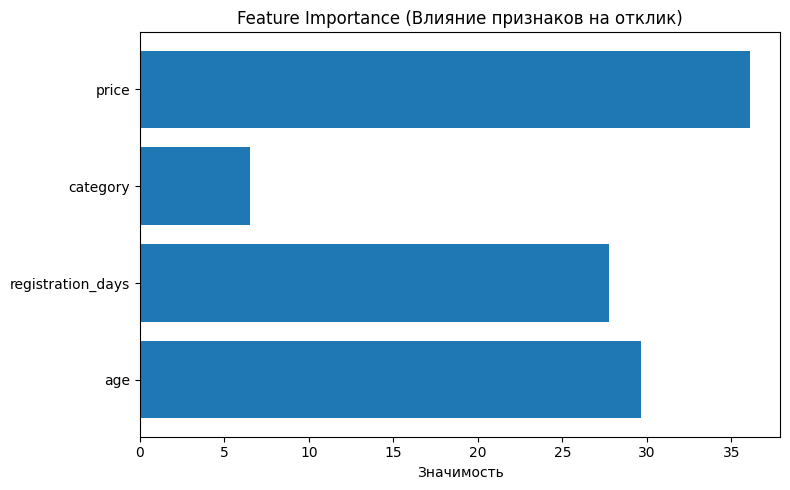

In [10]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

feature_importances = model.get_feature_importance(train_pool)
feature_names = X_train.columns

plt.figure(figsize=(8, 5))
plt.barh(feature_names, feature_importances)
plt.title('Feature Importance (Влияние признаков на отклик)')
plt.xlabel('Значимость')
plt.tight_layout()
plt.show()